In [ ]:
"""

Vanilla GAN (Original GAN)
"Generative Adversarial Nets" (Goodfellow et al., 2014)

Loss
- BCE(Binary Cross Entropy)

"""

'\n\nVanilla GAN (Original GAN)\n"Generative Adversarial Nets" (Goodfellow et al., 2014)\n\nLoss\n- BCE(Binary Cross Entropy)\n\n'

In [ ]:
import os

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision

from tqdm import tqdm
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("spandan2/cats-faces-64x64-for-generative-models")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cats-faces-64x64-for-generative-models' dataset.
Path to dataset files: /kaggle/input/cats-faces-64x64-for-generative-models


In [ ]:
# Optimize convolution algorithms for fixed input sizes to boost training speed
torch.backends.cudnn.benchmark = True

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

total_step = 5000
batch_size = 64
latent_size = 100

lr = 0.0002

In [ ]:
PRINT_INTERVAL = 25
SAMPLE_INTERVAL = 200
CHECKPOINT_INTERVAL = 1000

sample_dir = "./samples"
checkpoint_dir = "./checkpoints"
os.makedirs(sample_dir, exist_ok=True)
os.makedirs(checkpoint_dir, exist_ok=True)

image shape: torch.Size([64, 3, 32, 32])
dataset size: 15747


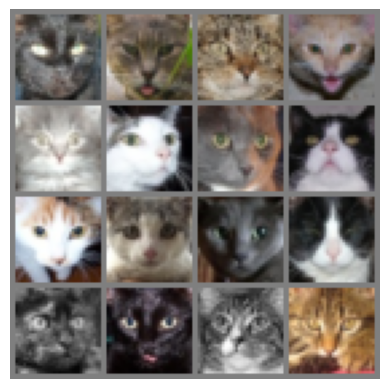

In [ ]:
class ImageDataLoader:
    def __init__(self, dataloader):
        self.dataloader = dataloader
        self.iterator = iter(dataloader)

    def __iter__(self):
        return self

    def __next__(self):
        try:
            return next(self.iterator)[0]
        except StopIteration:
            self.iterator = iter(self.dataloader)
            return next(self.iterator)[0]

transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

dataset = datasets.ImageFolder(root=path, transform=transform)
data_loader = DataLoader(
    dataset=dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True
)
train_loader = ImageDataLoader(data_loader)

# Test
images = next(iter(train_loader))
print(f"image shape: {images.shape}")
print(f"dataset size: {len(dataset) // 2}")

images = torchvision.utils.make_grid(images[:16], nrow=4)
images = (images + 1) / 2 # [-1, 1] -> [0, 1]
plt.imshow(images.permute(1, 2, 0))
plt.axis("off")
plt.show()

In [ ]:
#################### Generator ####################

class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(latent_size, 128),
            nn.LeakyReLU(0.2),

            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(0.2),

            nn.Linear(1024, 3 * 32 * 32),
            nn.Tanh()
        )

    def forward(self, z):
        image = self.network(z)
        image = image.view(image.size(0), 3, 32, 32)
        return image

In [ ]:
#################### Discriminator ####################

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(3 * 32 * 32, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, image):
        image = image.view(image.size(0), -1) # flatten
        output = self.network(image)
        return output

In [ ]:
def visualize_sample(fixed_z, step):
    generator.eval()
    with torch.no_grad():
        fake_images = generator(fixed_z).cpu()
        fake_images = (fake_images + 1) / 2  # [-1, 1] -> [0, 1]

        grid = torchvision.utils.make_grid(fake_images, nrow=8)
        plt.figure(figsize=(16, 4))
        plt.imshow(grid.permute(1, 2, 0))
        plt.axis("off")
        plt.tight_layout()
        plt.show()

        torchvision.utils.save_image(
            fake_images,
            f"{sample_dir}/step_{step:03d}.png",
            nrow=8
        )
    generator.train()

def save_checkpoint(step):
    torch.save({
        "step": step,
        "generator": generator.state_dict(),
        "discriminator": discriminator.state_dict(),
        "optimizer_G": optimizer_G.state_dict(),
        "optimizer_D": optimizer_D.state_dict(),
    }, f"{checkpoint_dir}/gan_step_{step:03d}.pth")

def load_checkpoint(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)

    generator.load_state_dict(checkpoint["generator"])
    discriminator.load_state_dict(checkpoint["discriminator"])
    optimizer_G.load_state_dict(checkpoint["optimizer_G"])
    optimizer_D.load_state_dict(checkpoint["optimizer_D"])
    start_step = checkpoint["step"]
    print(f"Loaded checkpoint: {checkpoint_path} (step {start_step})")
    return start_step

In [ ]:
generator = Generator().to(device)
discriminator = Discriminator().to(device)

criterion = nn.BCELoss()

optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.99))
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.99))

In [ ]:
# if pretrained
# path = "./checkpoints/gan_epoch_1000.pth"
# start_step = load_checkpoint(path)
start_step = 0

D_loss: 1.0129  G_loss: 1.5869  D(x): 0.684  D(G(z)): 0.280:   4%|▍         | 199/5000 [00:41<16:40,  4.80it/s]

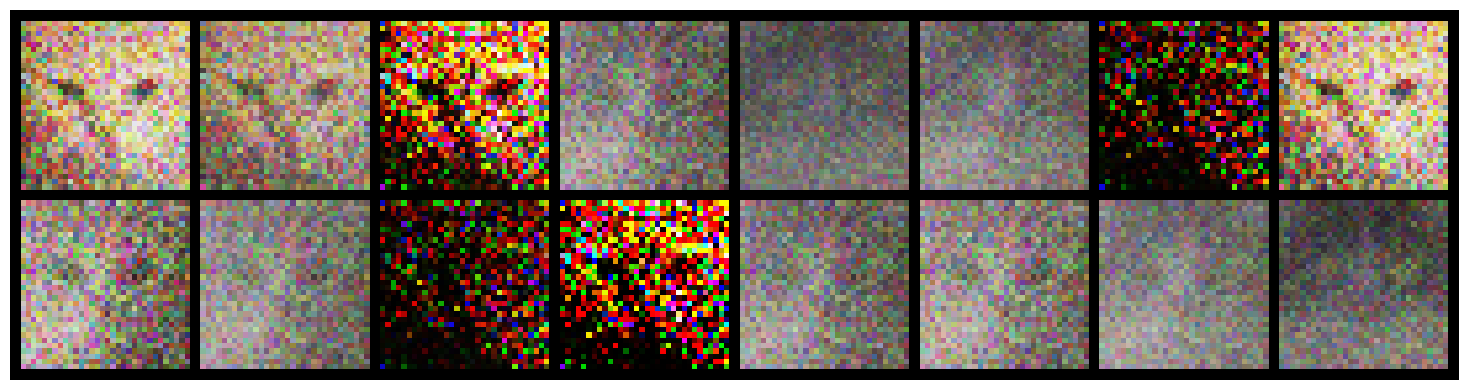

D_loss: 1.3153  G_loss: 2.1103  D(x): 0.644  D(G(z)): 0.218:   8%|▊         | 399/5000 [01:27<17:44,  4.32it/s]

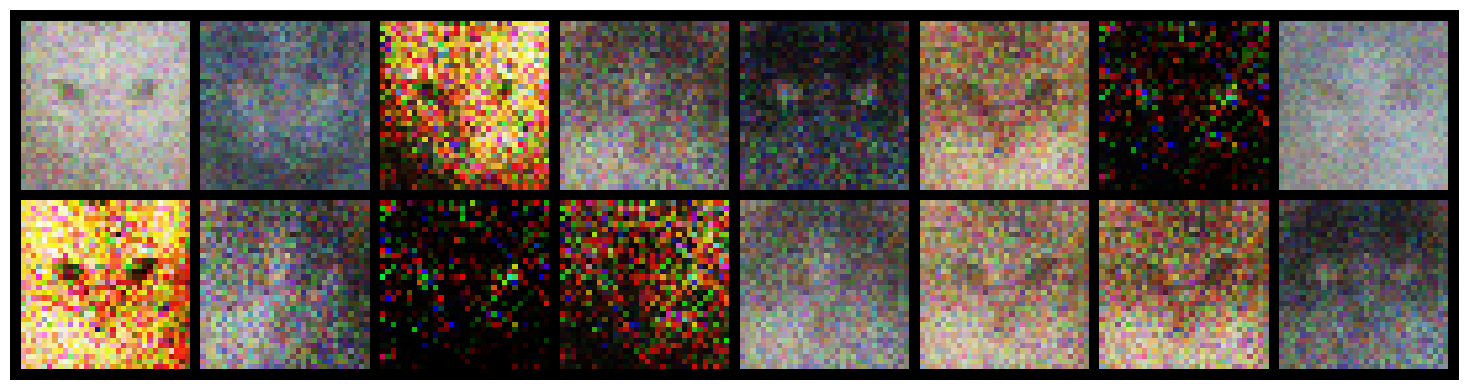

D_loss: 1.1929  G_loss: 1.6279  D(x): 0.555  D(G(z)): 0.241:  12%|█▏        | 599/5000 [01:58<06:32, 11.22it/s]

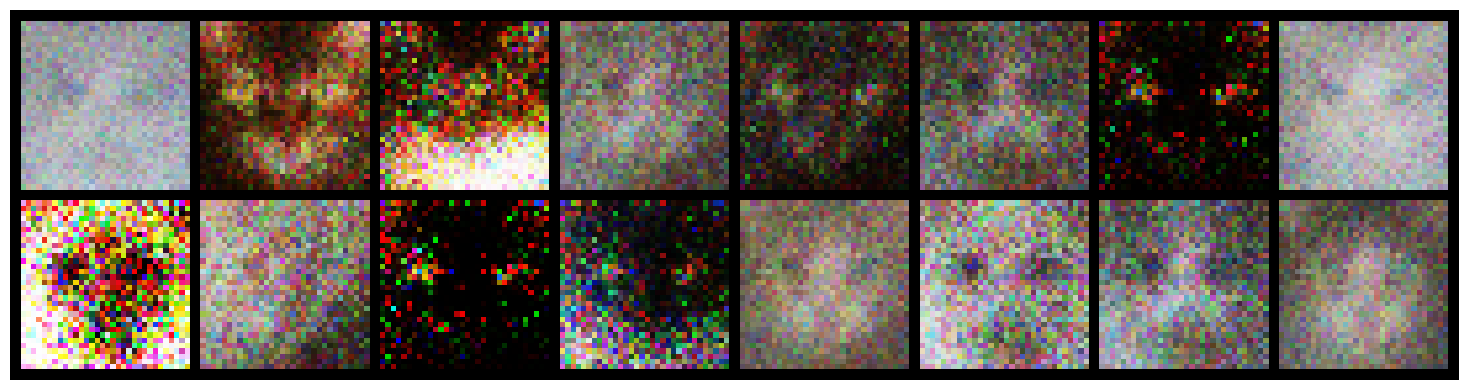

D_loss: 1.2450  G_loss: 1.2575  D(x): 0.494  D(G(z)): 0.299:  16%|█▌        | 799/5000 [02:16<06:14, 11.23it/s]

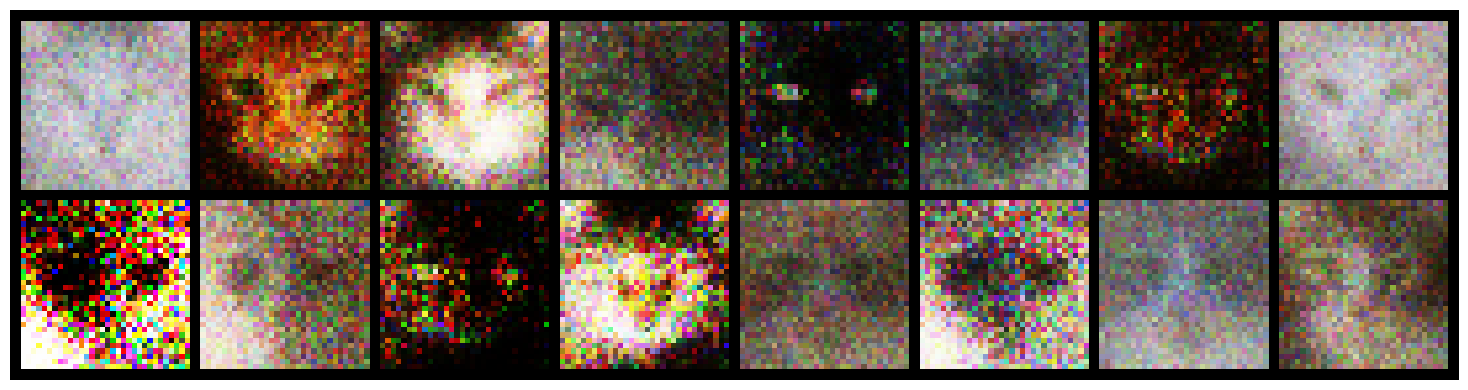

D_loss: 1.2624  G_loss: 1.2388  D(x): 0.543  D(G(z)): 0.303:  20%|█▉        | 999/5000 [02:35<06:01, 11.08it/s]

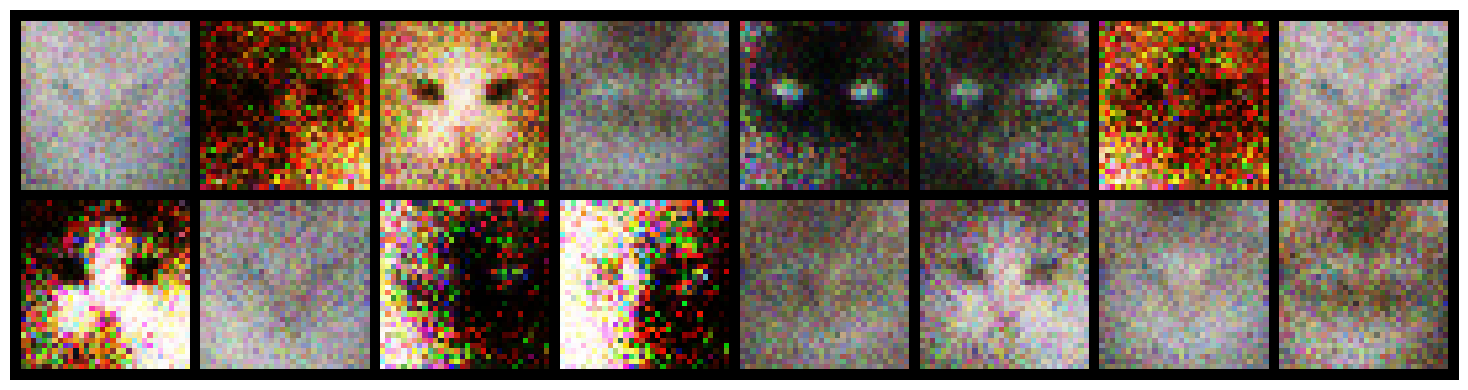

D_loss: 1.2832  G_loss: 1.0729  D(x): 0.556  D(G(z)): 0.367:  24%|██▍       | 1198/5000 [02:53<05:53, 10.76it/s]

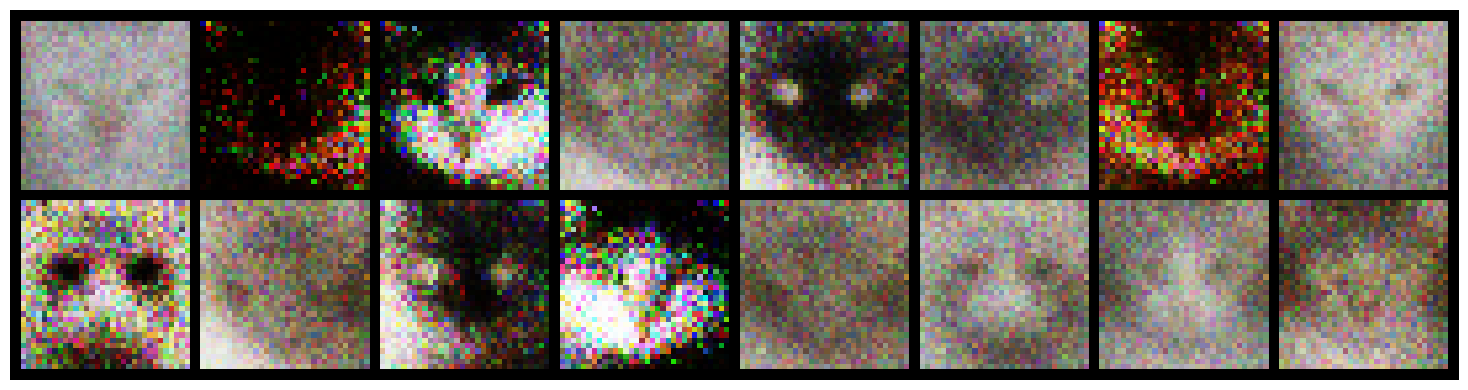

D_loss: 1.2514  G_loss: 1.1595  D(x): 0.562  D(G(z)): 0.335:  28%|██▊       | 1398/5000 [03:12<05:24, 11.09it/s]

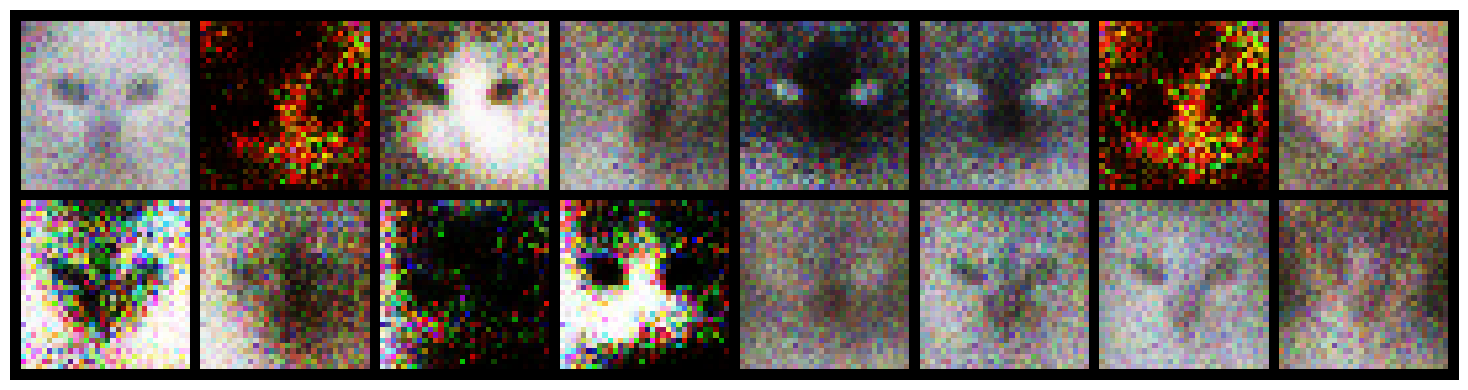

D_loss: 1.3252  G_loss: 1.0409  D(x): 0.528  D(G(z)): 0.373:  32%|███▏      | 1599/5000 [03:31<05:45,  9.84it/s]

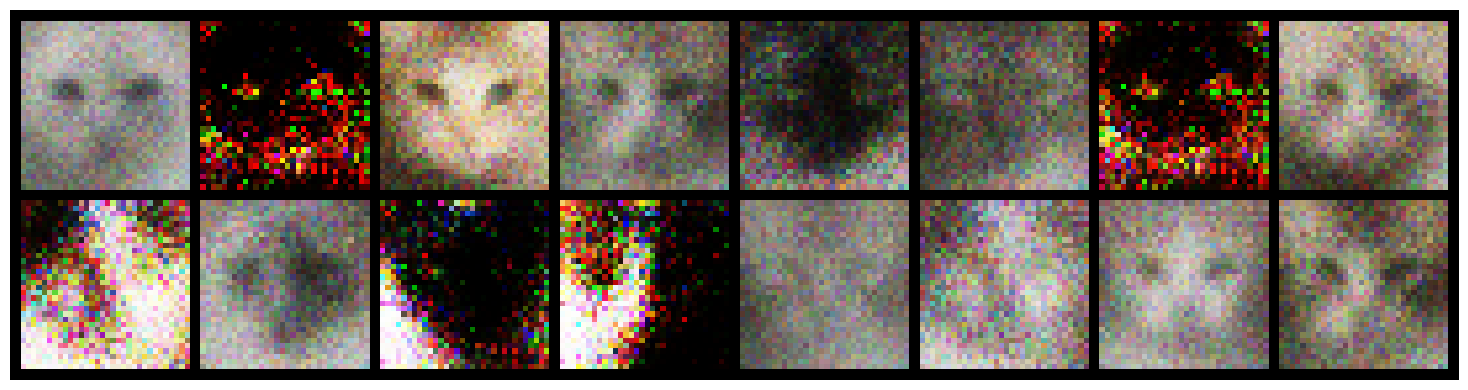

D_loss: 1.3301  G_loss: 0.9536  D(x): 0.525  D(G(z)): 0.410:  36%|███▌      | 1799/5000 [03:50<04:48, 11.10it/s]

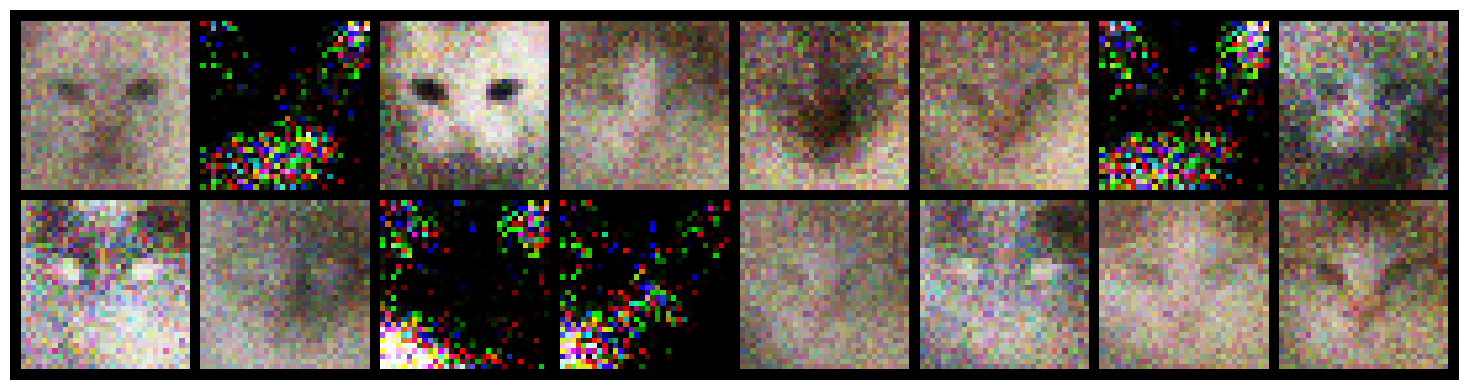

D_loss: 1.2537  G_loss: 0.8536  D(x): 0.558  D(G(z)): 0.432:  40%|███▉      | 1999/5000 [04:08<05:24,  9.26it/s]

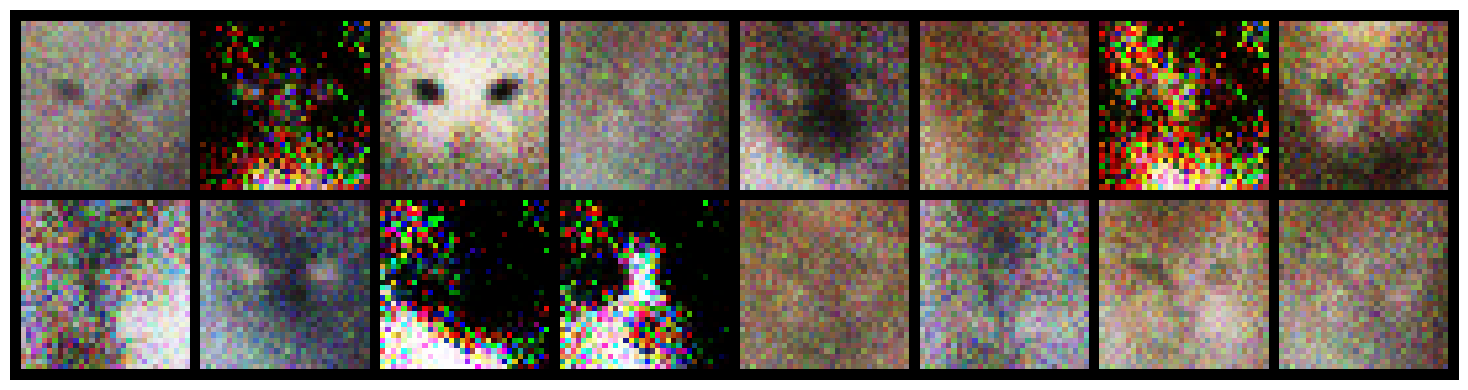

D_loss: 1.2115  G_loss: 0.9944  D(x): 0.564  D(G(z)): 0.388:  44%|████▍     | 2199/5000 [04:27<04:14, 10.99it/s]

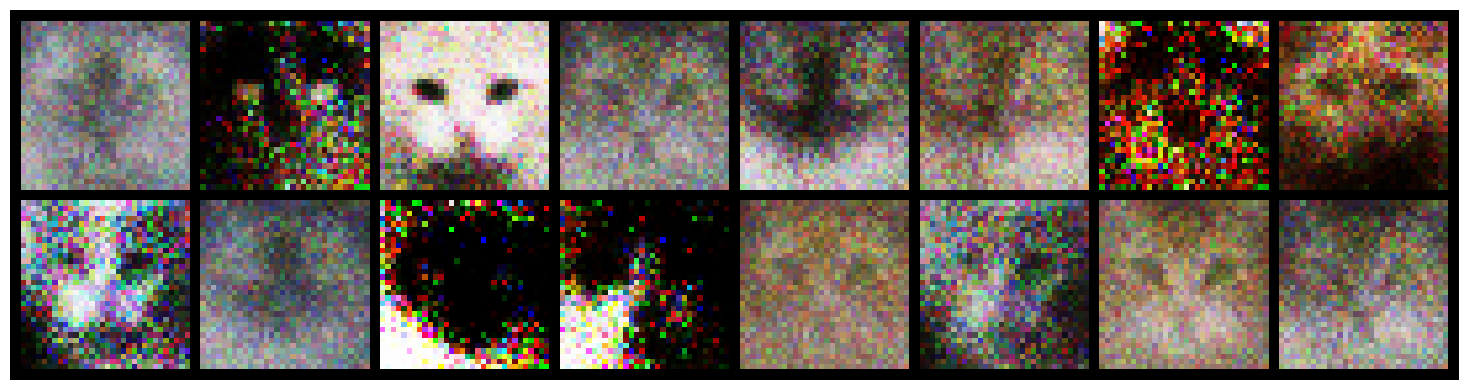

D_loss: 1.4062  G_loss: 0.8742  D(x): 0.514  D(G(z)): 0.430:  48%|████▊     | 2399/5000 [04:46<04:09, 10.41it/s]

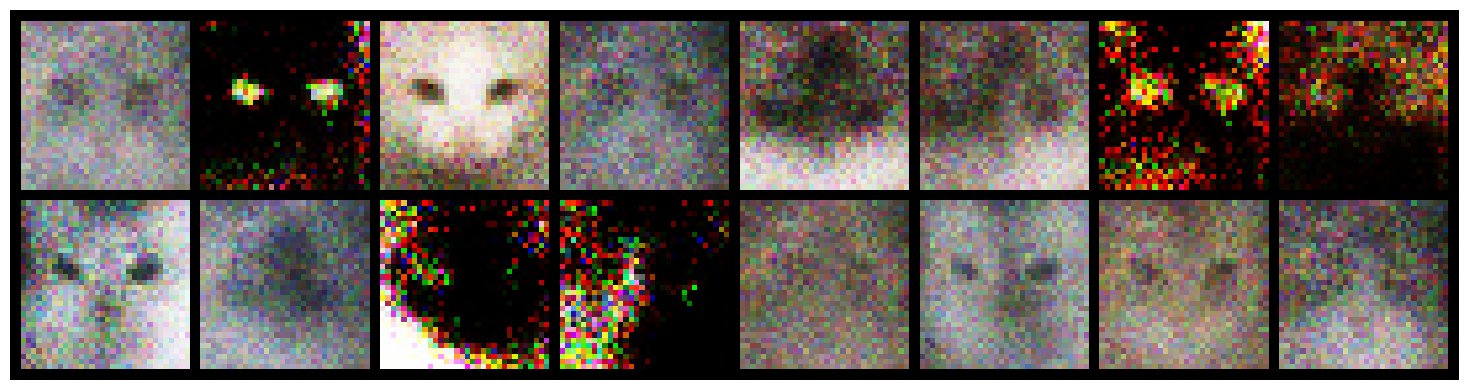

D_loss: 1.3235  G_loss: 0.8012  D(x): 0.550  D(G(z)): 0.457:  52%|█████▏    | 2599/5000 [05:05<03:34, 11.17it/s]

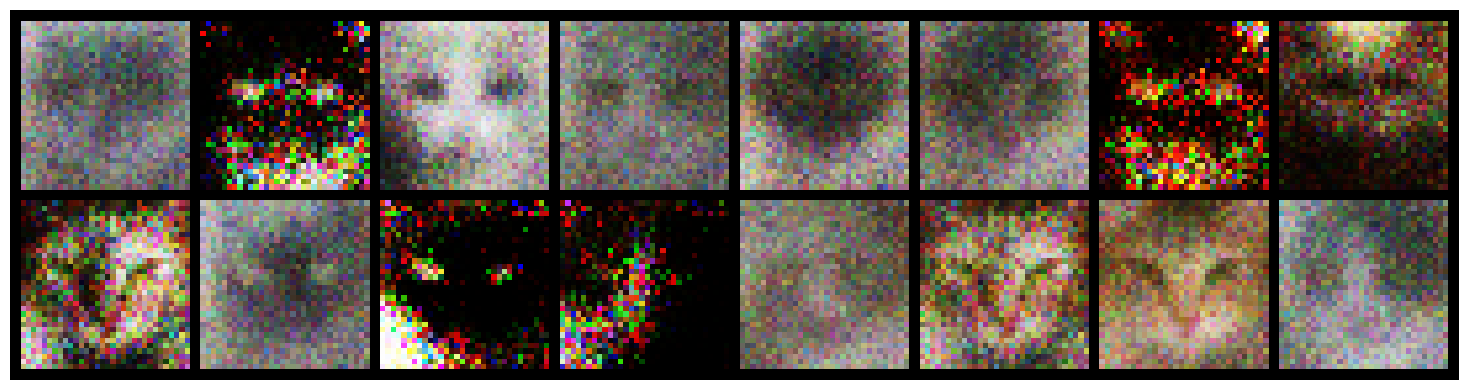

D_loss: 1.4383  G_loss: 0.7740  D(x): 0.476  D(G(z)): 0.475:  56%|█████▌    | 2798/5000 [05:24<03:22, 10.90it/s]

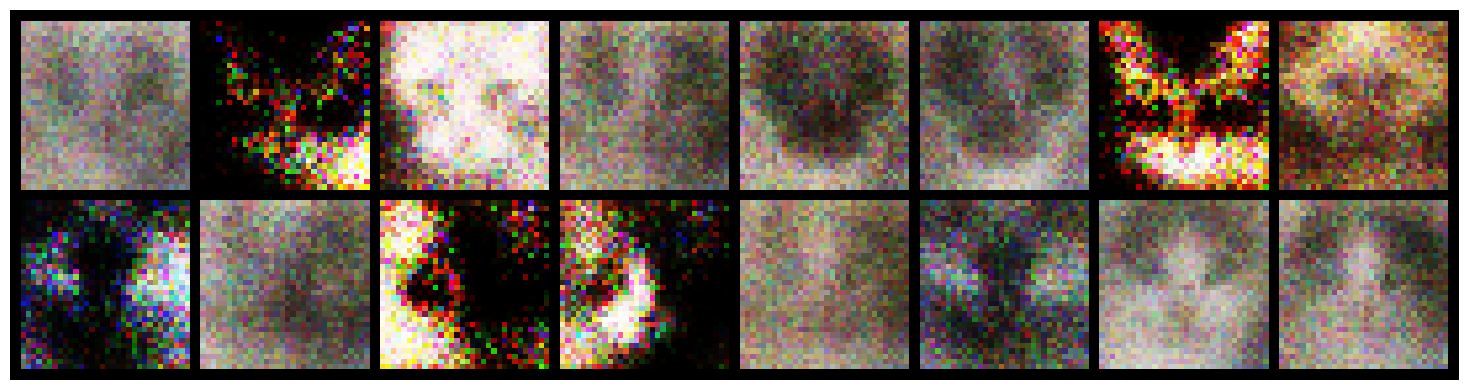

D_loss: 1.3799  G_loss: 0.9180  D(x): 0.485  D(G(z)): 0.408:  60%|█████▉    | 2998/5000 [05:42<03:00, 11.11it/s]

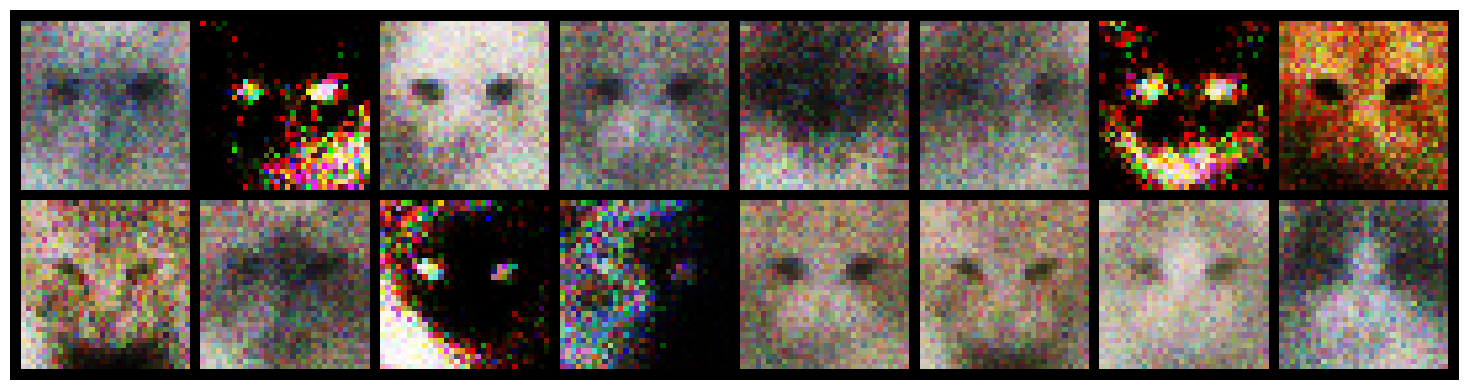

D_loss: 1.3251  G_loss: 0.9319  D(x): 0.520  D(G(z)): 0.402:  64%|██████▍   | 3198/5000 [06:01<02:46, 10.82it/s]

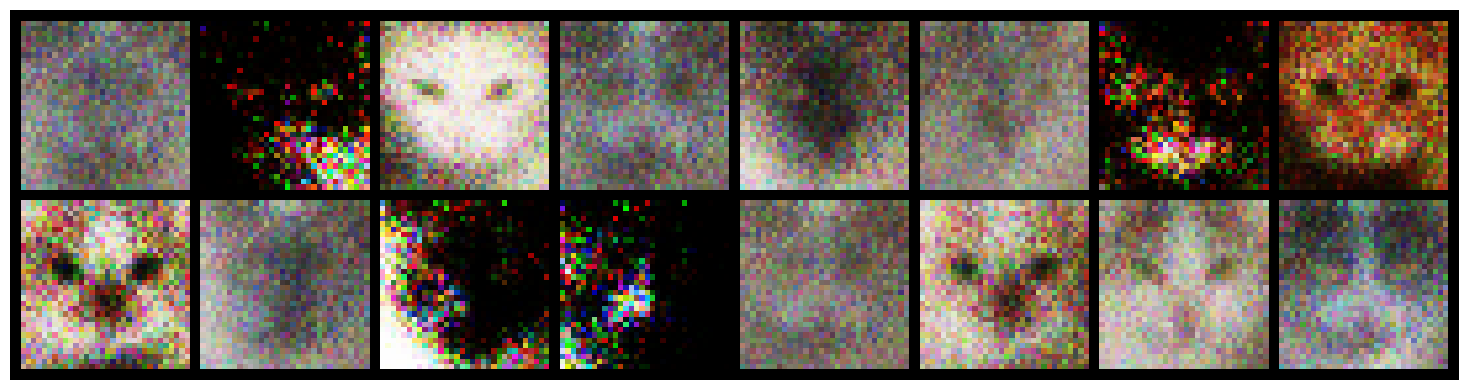

D_loss: 1.3402  G_loss: 0.8304  D(x): 0.549  D(G(z)): 0.445:  68%|██████▊   | 3399/5000 [06:20<02:28, 10.80it/s]

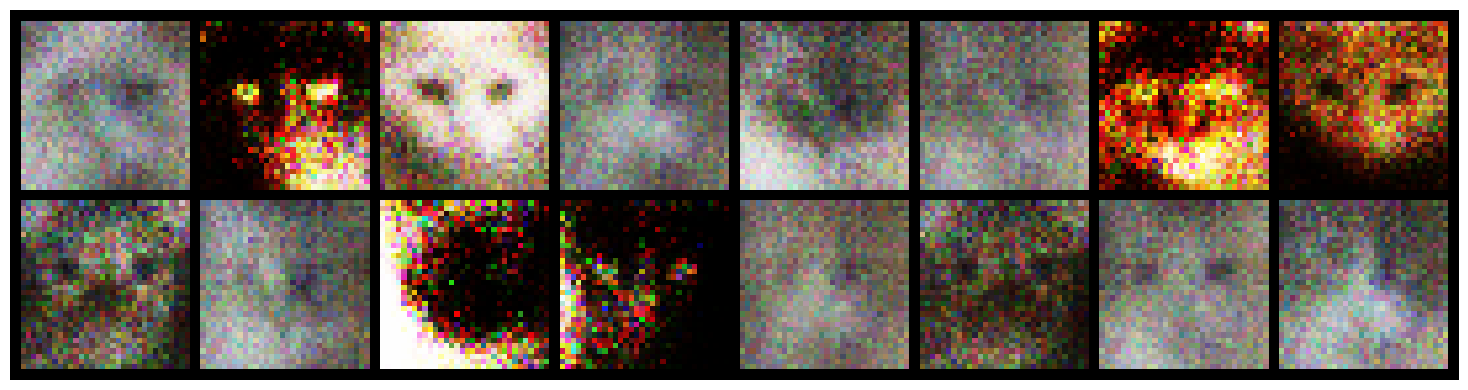

D_loss: 1.2465  G_loss: 0.9135  D(x): 0.558  D(G(z)): 0.412:  72%|███████▏  | 3598/5000 [06:39<02:06, 11.07it/s]

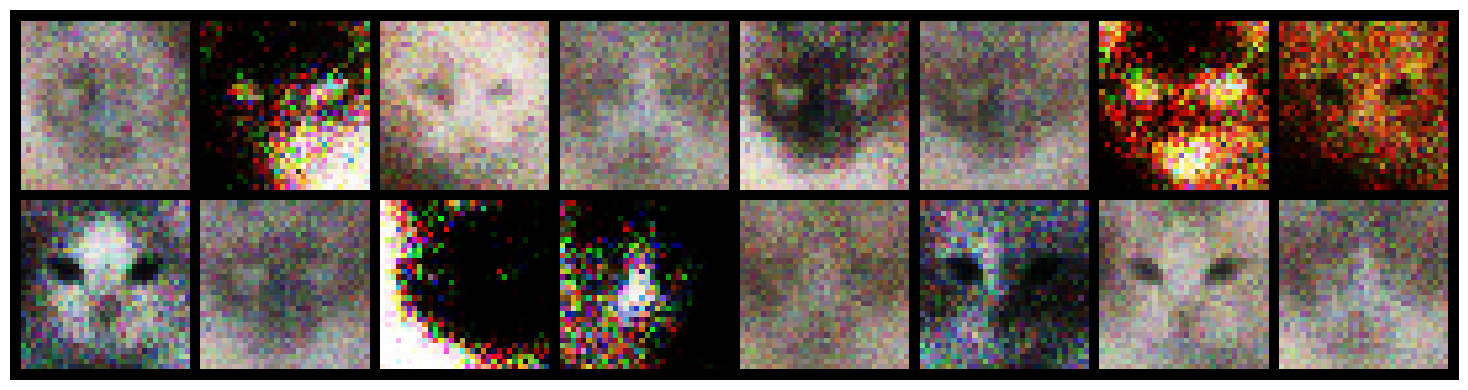

D_loss: 1.4087  G_loss: 0.8722  D(x): 0.479  D(G(z)): 0.426:  76%|███████▌  | 3799/5000 [06:57<01:48, 11.03it/s]

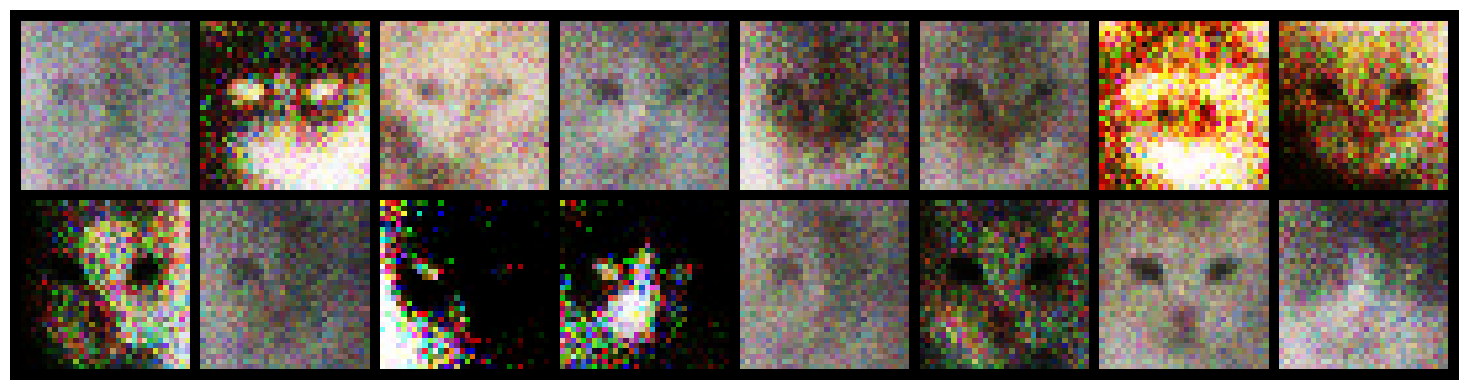

D_loss: 1.3812  G_loss: 0.7677  D(x): 0.552  D(G(z)): 0.468:  80%|███████▉  | 3999/5000 [07:17<01:28, 11.28it/s]

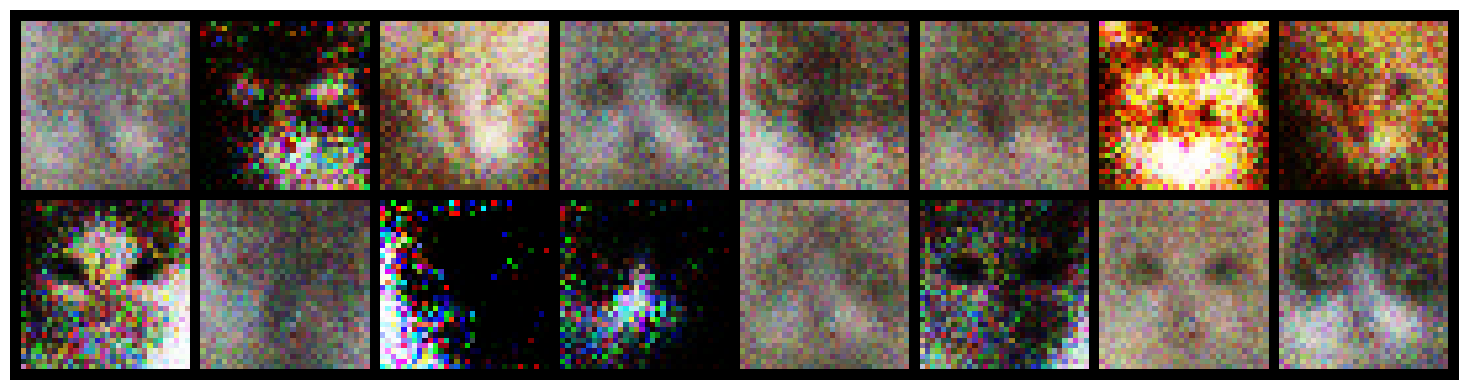

D_loss: 1.3656  G_loss: 0.8269  D(x): 0.507  D(G(z)): 0.446:  84%|████████▍ | 4199/5000 [07:35<01:11, 11.19it/s]

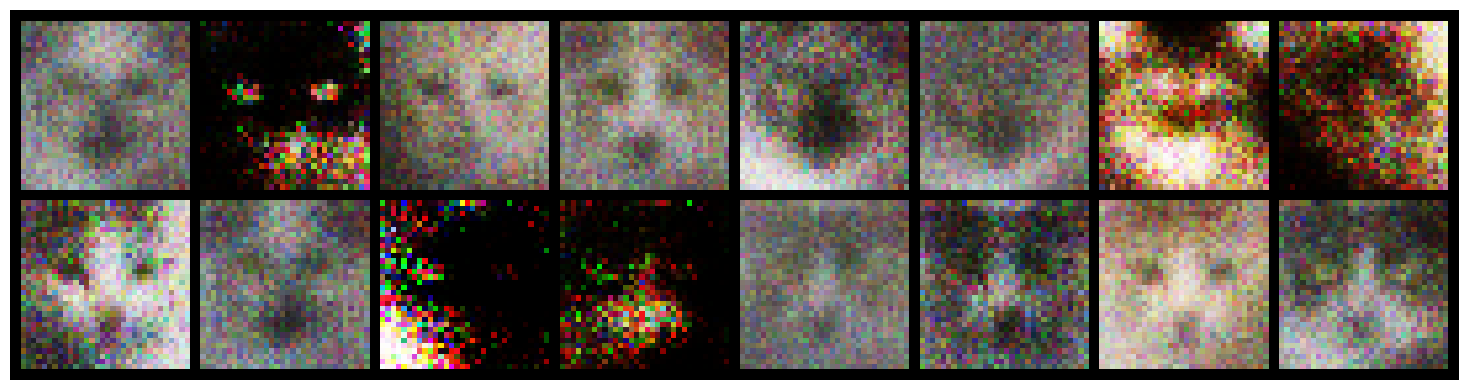

D_loss: 1.3982  G_loss: 0.9871  D(x): 0.480  D(G(z)): 0.383:  88%|████████▊ | 4399/5000 [07:54<00:54, 11.06it/s]

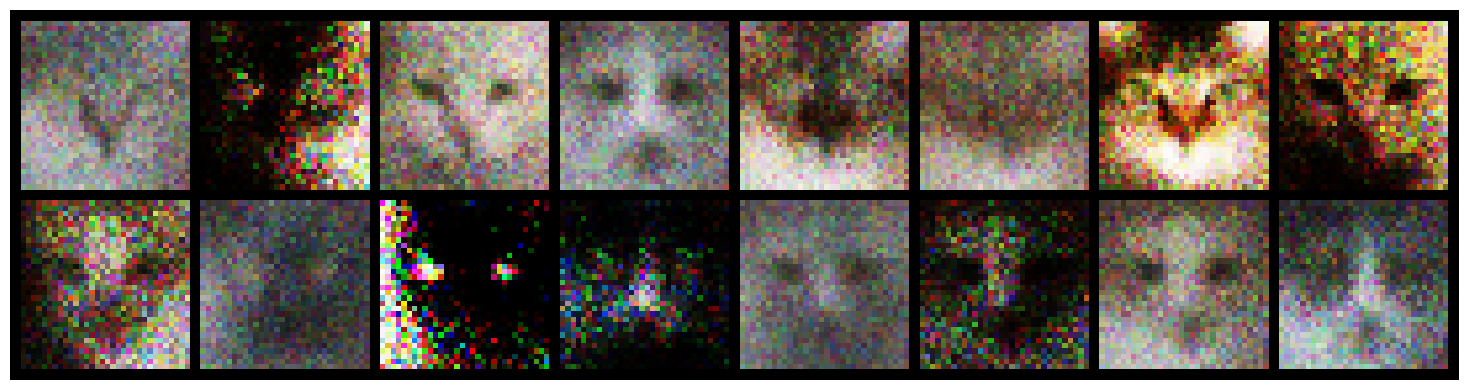

D_loss: 1.4493  G_loss: 0.9864  D(x): 0.512  D(G(z)): 0.384:  92%|█████████▏| 4599/5000 [08:13<00:36, 11.03it/s]

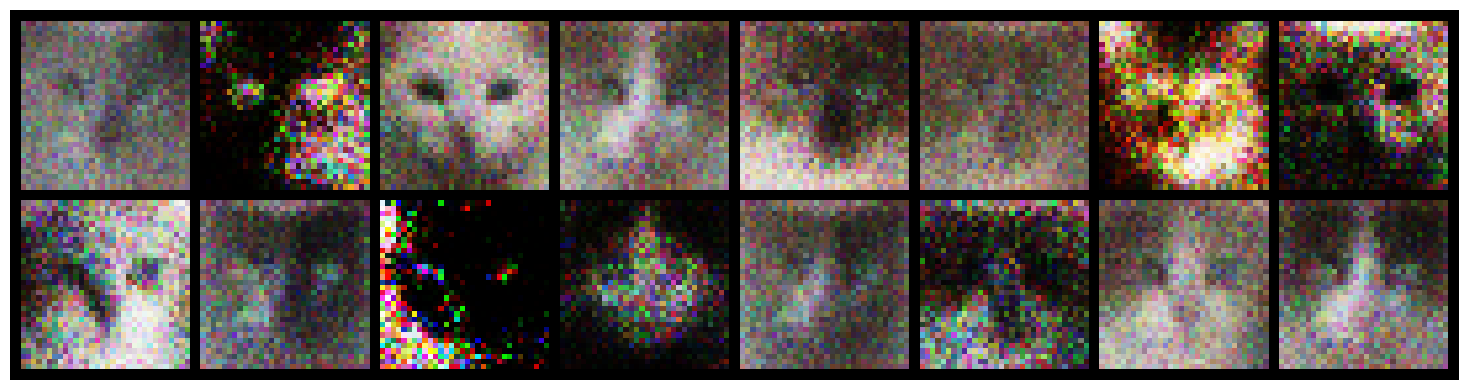

D_loss: 1.3962  G_loss: 1.0485  D(x): 0.458  D(G(z)): 0.358:  96%|█████████▌| 4798/5000 [08:32<00:17, 11.30it/s]

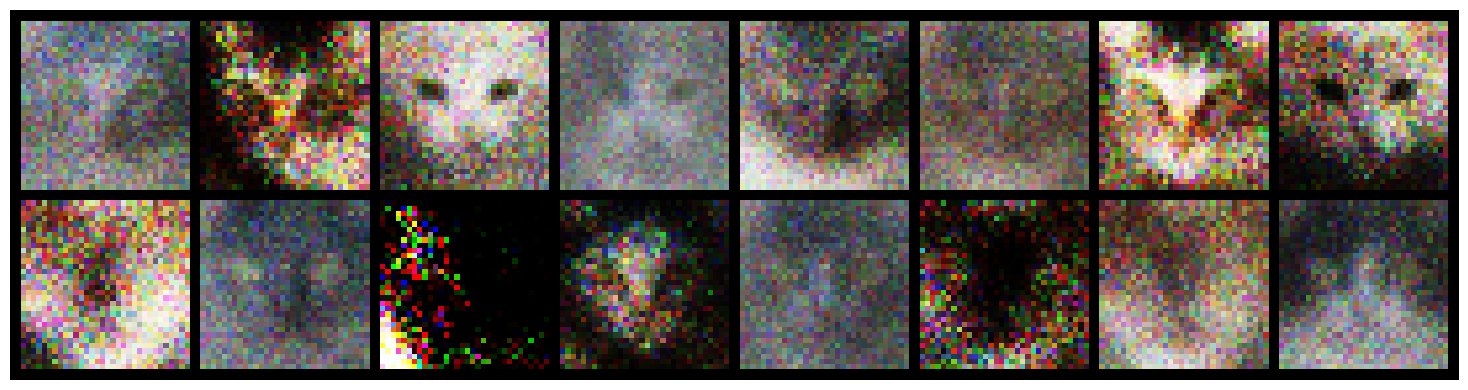

D_loss: 1.4107  G_loss: 0.9763  D(x): 0.453  D(G(z)): 0.394: 100%|█████████▉| 4999/5000 [08:51<00:00, 11.20it/s]

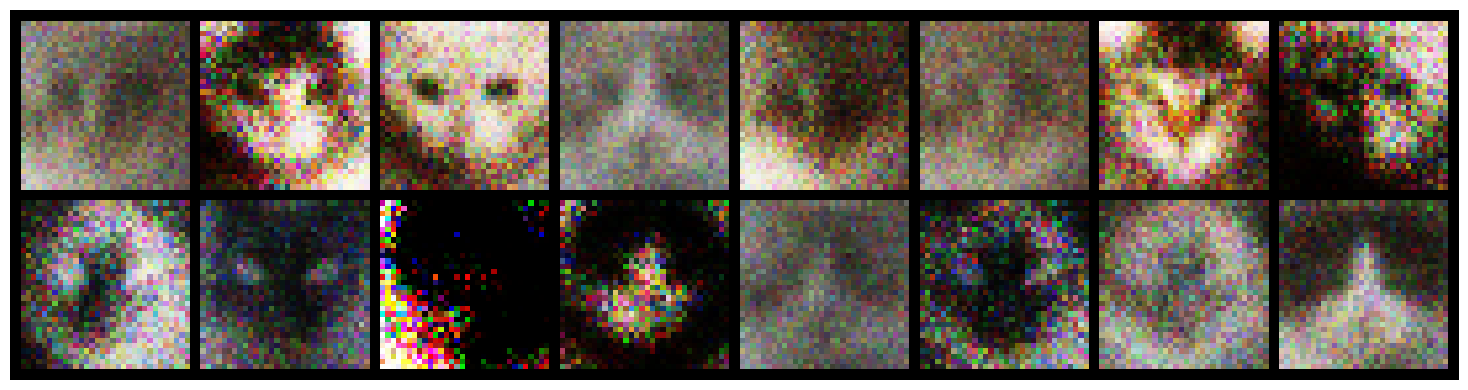

D_loss: 1.4107  G_loss: 0.9763  D(x): 0.453  D(G(z)): 0.394: 100%|██████████| 5000/5000 [08:51<00:00,  9.41it/s]


In [ ]:
########## Train ##########

fixed_z_generator = torch.Generator(device=device).manual_seed(42)
fixed_z = torch.randn(16, latent_size, generator=fixed_z_generator, device=device) # for eval
real_targets = torch.ones(batch_size, 1, device=device)  # (b, 1)
fake_targets = torch.zeros(batch_size, 1, device=device) # (b, 1)

pbar = tqdm(range(start_step, total_step), desc="VanillaGAN")

for step in pbar:
    real_images = next(train_loader).to(device)

    ########## D Train ##########
    z = torch.randn(batch_size, latent_size, device=device)
    with torch.no_grad():
        fake_images = generator(z)

    d_real = discriminator(real_images)
    d_fake = discriminator(fake_images)
    real_loss = criterion(d_real, real_targets)
    fake_loss = criterion(d_fake, fake_targets)

    loss_D = real_loss + fake_loss

    optimizer_D.zero_grad()
    loss_D.backward()
    optimizer_D.step()


    ########## G Train ##########
    z = torch.randn(batch_size, latent_size, device=device)
    fake_images = generator(z)
    d_fake = discriminator(fake_images)
    loss_G = criterion(d_fake, real_targets)

    optimizer_G.zero_grad()
    loss_G.backward()
    optimizer_G.step()

    ########## Log ##########

    if (step + 1) % PRINT_INTERVAL == 0:
        pbar.set_description(
            f"D_loss: {loss_D.item():.4f}  G_loss: {loss_G.item():.4f}  "
            f"D(x): {d_real.mean().item():.3f}  D(G(z)): {d_fake.mean().item():.3f}"
        )

    if (step + 1) % SAMPLE_INTERVAL == 0:
        visualize_sample(fixed_z, step + 1)

    if (step + 1) % CHECKPOINT_INTERVAL == 0:
        save_checkpoint(step + 1)